# Active Fourier Modes Visualization

## User Parameters
Edit the variables in the next cell to switch data size, kernel, active-set size, color field, discretization tolerance, regularization, and the dense toy settings for matrix/spectrum intuition figures. The notebook validates choices before doing any computation and prints the current settings plus figure diagnostics.

The figure sequence is organized around the paper intuition: EFGP cost is dominated by repeated Fourier weight-space solves; the Fourier weights create low-frequency spectral concentration; a box-preserving active inverse improves the dense toy spectrum while the tail is summarized through normalized coupling diagnostics.


In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

# ---- Editable choices -----------------------------------------------------
N_TRAIN_OPTIONS = [8192000]
ACTIVE_TOPK_OPTIONS = [256, 512, 1024, 2048]
KERNEL_OPTIONS = {
    "matern": {"lengthscale": 0.1, "nu": 1.5, "variance": 1.0},
    "squared_exponential": {"lengthscale": 0.1, "variance": 1.0},
}
COLOR_FIELD_OPTIONS = ["rho", "D_abs"]
RHO_REFERENCE_LEVEL_OPTIONS = [0.1, 0.3, 1.0, 3.0,10.0,100]
EPS_OPTIONS = [1e-4, 1e-5, 1e-6]
REG_LAMBDA_OPTIONS = [1e-2, 1e-1, 1.0]
NOISE_STD_OPTIONS = [0.02, 0.1, 0.2, 0.5, 1.0]
EIG_COMPRESSED_RANK_OPTIONS = [8, 16, 32, 64, 96, 128, 160,256]

N_TRAIN = 8192000
ACTIVE_TOPK = 2048
KERNEL_NAME = "matern"
COLOR_FIELD = "rho"
RHO_REFERENCE_LEVEL = 10
EPS = 1e-5
REG_LAMBDA = 1e-1

# Fixed defaults for this figure-generation notebook.
NOISE_STD = 0.5
SEED = 20260421
NUFFT_TOL = 1e-10
L2_SCALED = True
ACTIVE_MODE = "topk"
BOX_BUDGET = None
MATRIX_TOY_HM = 40
MATRIX_ACTIVE_TOPK = 1024
MATRIX_MAX_HEATMAP_SIZE = 1800
EIG_COMPRESSED_RANK = 256
OUTPUT_BASENAME_ACTIVE = "active_set_fourier_modes"
OUTPUT_BASENAME_DECAY = "rho_radial_mass_profile"
OUTPUT_BASENAME_BLOCKS = "matrix_block_structure"
OUTPUT_BASENAME_TAIL = "normalized_tail_couplings"
OUTPUT_BASENAME_SPECTRUM = "preconditioning_effect_spectrum"


def _find_repo_root_and_notebook_dir() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        candidate = base / "efgp_eigenpro_py" / "gpu" / "box_toeplitz_active_block"
        if candidate.exists():
            return base, candidate
    if cwd.name == "box_toeplitz_active_block":
        return cwd.parents[2], cwd
    raise RuntimeError("Could not locate repo root containing efgp_eigenpro_py/gpu/box_toeplitz_active_block.")


REPO_ROOT, NOTEBOOK_DIR = _find_repo_root_and_notebook_dir()
PICTURE_DIR = NOTEBOOK_DIR / "picture"
PICTURE_DIR.mkdir(parents=True, exist_ok=True)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def _validate_choice(name: str, value, options) -> None:
    if value not in options:
        raise ValueError(f"{name}={value!r} is invalid. Choose one of: {list(options)!r}")


_validate_choice("N_TRAIN", N_TRAIN, N_TRAIN_OPTIONS)
_validate_choice("ACTIVE_TOPK", ACTIVE_TOPK, ACTIVE_TOPK_OPTIONS)
_validate_choice("KERNEL_NAME", KERNEL_NAME, KERNEL_OPTIONS.keys())
_validate_choice("COLOR_FIELD", COLOR_FIELD, COLOR_FIELD_OPTIONS)
_validate_choice("RHO_REFERENCE_LEVEL", RHO_REFERENCE_LEVEL, RHO_REFERENCE_LEVEL_OPTIONS)
_validate_choice("EPS", EPS, EPS_OPTIONS)
_validate_choice("REG_LAMBDA", REG_LAMBDA, REG_LAMBDA_OPTIONS)
_validate_choice("NOISE_STD", NOISE_STD, NOISE_STD_OPTIONS)
_validate_choice("EIG_COMPRESSED_RANK", EIG_COMPRESSED_RANK, EIG_COMPRESSED_RANK_OPTIONS)

_rows = [
    ("N_TRAIN", N_TRAIN),
    ("ACTIVE_TOPK", ACTIVE_TOPK),
    ("KERNEL_NAME", KERNEL_NAME),
    ("KERNEL_OPTIONS[KERNEL_NAME]", KERNEL_OPTIONS[KERNEL_NAME]),
    ("COLOR_FIELD", COLOR_FIELD),
    ("RHO_REFERENCE_LEVEL", RHO_REFERENCE_LEVEL),
    ("EPS", EPS),
    ("REG_LAMBDA", REG_LAMBDA),
    ("NOISE_STD", NOISE_STD),
    ("SEED", SEED),
    ("L2_SCALED", L2_SCALED),
    ("ACTIVE_MODE", ACTIVE_MODE),
    ("MATRIX_TOY_HM", MATRIX_TOY_HM),
    ("MATRIX_ACTIVE_TOPK", MATRIX_ACTIVE_TOPK),
    ("MATRIX_MAX_HEATMAP_SIZE", MATRIX_MAX_HEATMAP_SIZE),
    ("EIG_COMPRESSED_RANK", EIG_COMPRESSED_RANK),
    ("PICTURE_DIR", str(PICTURE_DIR)),
]
_name_width = max(len(str(k)) for k, _ in _rows)
print("Current parameters")
print("-" * 80)
for key, value in _rows:
    print(f"{key:<{_name_width}} : {value}")


Current parameters
--------------------------------------------------------------------------------
N_TRAIN                     : 8192000
ACTIVE_TOPK                 : 2048
KERNEL_NAME                 : matern
KERNEL_OPTIONS[KERNEL_NAME] : {'lengthscale': 0.1, 'nu': 1.5, 'variance': 1.0}
COLOR_FIELD                 : rho
RHO_REFERENCE_LEVEL         : 10
EPS                         : 1e-05
REG_LAMBDA                  : 0.1
NOISE_STD                   : 0.5
SEED                        : 20260421
L2_SCALED                   : True
ACTIVE_MODE                 : topk
MATRIX_TOY_HM               : 30
MATRIX_ACTIVE_TOPK          : 1024
MATRIX_MAX_HEATMAP_SIZE     : 1800
EIG_COMPRESSED_RANK         : 256
PICTURE_DIR                 : D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture


## Build Synthetic Data and Fourier Quantities
This uses the repository's 2D synthetic regression helper and the same EFGP Fourier grid/weight formulas used by the solver.

In [75]:
import math
import time

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

from efgp_eigenpro_py.benchmark import make_dataset, true_func_2d
from efgp_eigenpro_py.discretization import basis_weights, choose_grid_params
from efgp_eigenpro_py.gpu.box_toeplitz_active_block.active_set import build_box_active_set
from efgp_eigenpro_py.kernels import make_matern, make_squared_exponential


def make_selected_kernel(name: str):
    spec = KERNEL_OPTIONS[name]
    if name == "matern":
        return make_matern(
            lengthscale=float(spec["lengthscale"]),
            nu=float(spec["nu"]),
            dim=2,
            variance=float(spec["variance"]),
        )
    if name == "squared_exponential":
        return make_squared_exponential(
            lengthscale=float(spec["lengthscale"]),
            dim=2,
            variance=float(spec["variance"]),
        )
    raise ValueError(f"Unsupported KERNEL_NAME={name!r}")


kernel = make_selected_kernel(KERNEL_NAME)
x_train, y_train = make_dataset(2, int(N_TRAIN), true_func_2d, noise=float(NOISE_STD), seed=int(SEED))
x_train = np.asarray(x_train, dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)

x_min = np.min(x_train, axis=0)
x_max = np.max(x_train, axis=0)
x_center = 0.5 * (x_min + x_max)
L = float(np.max(x_max - x_min))
grid = choose_grid_params(kernel, float(EPS), L, l2scaled=bool(L2_SCALED))
weights_flat = np.ascontiguousarray(basis_weights(kernel, grid.xis, grid.h).reshape(-1))
weights_grid = weights_flat.reshape(grid.mtot, grid.mtot)

if int(ACTIVE_TOPK) > int(weights_flat.size):
    raise ValueError(
        f"ACTIVE_TOPK={ACTIVE_TOPK} exceeds M={weights_flat.size}. "
        f"Choose one of {ACTIVE_TOPK_OPTIONS!r} that is <= M."
    )

gamma = float(N_TRAIN)
active = build_box_active_set(
    gamma=gamma,
    weights=weights_flat,
    reg_lambda=float(REG_LAMBDA),
    mtot=int(grid.mtot),
    dim=2,
    active_mode=str(ACTIVE_MODE),
    active_topk=int(ACTIVE_TOPK),
    active_tau=None,
    box_budget=BOX_BUDGET,
)

j = np.arange(-grid.hm, grid.hm + 1, dtype=np.int64)
J1, J2 = np.meshgrid(j, j, indexing="ij")
rho_grid = active.rho.reshape(grid.mtot, grid.mtot)
D_abs_grid = np.abs(weights_grid)
diag_A_grid = gamma * (D_abs_grid ** 2) + float(REG_LAMBDA)
active_multi = np.stack(np.unravel_index(active.active_idx, (grid.mtot, grid.mtot)), axis=1)
active_j = active_multi - active.center_multi[None, :]
box_radii = np.asarray(active.radii, dtype=np.int64)

summary_rows = [
    ("kernel", repr(kernel)),
    ("L", f"{L:.6g}"),
    ("h", f"{grid.h:.6g}"),
    ("hm", int(grid.hm)),
    ("mtot", int(grid.mtot)),
    ("M", int(weights_flat.size)),
    ("gamma", f"{gamma:.6g}"),
    ("active_size", int(active.active_idx.size)),
    ("box_radii", box_radii.tolist()),
    ("box_size", int(active.box_idx.size)),
]
_name_width = max(len(str(k)) for k, _ in summary_rows)
print("Computed quantities")
print("-" * 80)
for key, value in summary_rows:
    print(f"{key:<{_name_width}} : {value}")

Computed quantities
--------------------------------------------------------------------------------
kernel      : KernelSpec(fam='matern', dim=2, lengthscale=0.1, variance=1.0, nu=1.5)
L           : 1
h           : 0.51838
hm          : 94
mtot        : 189
M           : 35721
gamma       : 8.192e+06
active_size : 2048
box_radii   : [25, 25]
box_size    : 2601


## Compute Toeplitz Generator and Real RHS
`G_lag` is data-dependent and is not used as a standalone decay argument here. It is computed so the notebook can assemble the dense toy matrix `A = D G D + lambda I`.

The RHS is now generated from the actual synthetic targets: `rhs = D Phi^* y`, using the same Fourier grid and scaling convention as the EFGP solver. A larger synthetic noise level can be selected in the parameter cell to make this RHS less idealized.

In [76]:
def _scaled_points_for_nufft(x: np.ndarray, center: np.ndarray, h: float) -> np.ndarray:
    upper = np.nextafter(np.pi, 0.0)
    tphx = 2.0 * np.pi * float(h) * (np.asarray(x, dtype=np.float64) - np.asarray(center, dtype=np.float64))
    return np.clip(tphx, -np.pi, upper)


def _xtxcol_finufft(tphx: np.ndarray, ms: int, tol: float) -> np.ndarray:
    from efgp_eigenpro_py.nufft_ops import nufft2d1

    coeff = np.ones(tphx.shape[0], dtype=np.complex128)
    return np.asarray(nufft2d1(tphx[:, 0], tphx[:, 1], coeff, ms, ms, float(tol), -1), dtype=np.complex128)


def _rhs_finufft(tphx: np.ndarray, y: np.ndarray, mtot: int, tol: float) -> np.ndarray:
    from efgp_eigenpro_py.nufft_ops import nufft2d1

    coeff = np.asarray(y, dtype=np.complex128).reshape(-1)
    return np.asarray(nufft2d1(tphx[:, 0], tphx[:, 1], coeff, int(mtot), int(mtot), float(tol), -1), dtype=np.complex128)


def _xtxcol_direct(tphx: np.ndarray, ms: int, *, block_modes: int = 32) -> np.ndarray:
    half = (int(ms) - 1) // 2
    lags = np.arange(-half, half + 1, dtype=np.float64)
    out = np.empty((int(ms), int(ms)), dtype=np.complex128)
    x0 = np.asarray(tphx[:, 0], dtype=np.float64)
    x1 = np.asarray(tphx[:, 1], dtype=np.float64)
    for i0 in range(0, int(ms), int(block_modes)):
        i1 = min(int(ms), i0 + int(block_modes))
        phase0 = np.exp(-1j * np.outer(lags[i0:i1], x0))
        for j0 in range(0, int(ms), int(block_modes)):
            j1 = min(int(ms), j0 + int(block_modes))
            phase1 = np.exp(-1j * np.outer(lags[j0:j1], x1))
            out[i0:i1, j0:j1] = phase0 @ phase1.T
    return out


def _rhs_direct(tphx: np.ndarray, y: np.ndarray, mtot: int, *, block_modes: int = 256) -> np.ndarray:
    hm = (int(mtot) - 1) // 2
    modes_1d = np.arange(-hm, hm + 1, dtype=np.float64)
    M1, M2 = np.meshgrid(modes_1d, modes_1d, indexing="ij")
    modes = np.stack([M1.reshape(-1), M2.reshape(-1)], axis=1)
    out = np.empty((modes.shape[0],), dtype=np.complex128)
    coeff = np.asarray(y, dtype=np.complex128).reshape(-1)
    x0 = np.asarray(tphx[:, 0], dtype=np.float64)
    x1 = np.asarray(tphx[:, 1], dtype=np.float64)
    for lo in range(0, modes.shape[0], int(block_modes)):
        hi = min(modes.shape[0], lo + int(block_modes))
        phase = np.exp(-1j * (modes[lo:hi, 0:1] * x0[None, :] + modes[lo:hi, 1:2] * x1[None, :]))
        out[lo:hi] = phase @ coeff
    return out.reshape(int(mtot), int(mtot))


tphx = _scaled_points_for_nufft(x_train, x_center, grid.h)
ms = 2 * int(grid.mtot) - 1
_t0 = time.perf_counter()
try:
    XtXcol = _xtxcol_finufft(tphx, ms, NUFFT_TOL)
    G_METHOD = "finufft"
except Exception as exc:
    print(f"FINUFFT unavailable or failed for G ({exc}); using chunked direct Fourier sum.")
    XtXcol = _xtxcol_direct(tphx, ms)
    G_METHOD = "direct"
_t1 = time.perf_counter()

_t_rhs0 = time.perf_counter()
try:
    rhs_unweighted = _rhs_finufft(tphx, y_train, int(grid.mtot), NUFFT_TOL)
    RHS_METHOD = "finufft"
except Exception as exc:
    print(f"FINUFFT unavailable or failed for RHS ({exc}); using chunked direct Fourier sum.")
    rhs_unweighted = _rhs_direct(tphx, y_train, int(grid.mtot))
    RHS_METHOD = "direct"
_t_rhs1 = time.perf_counter()
rhs_flat = np.ascontiguousarray(rhs_unweighted.reshape(-1))
np.multiply(weights_flat, rhs_flat, out=rhs_flat)
rhs_grid = rhs_flat.reshape(int(grid.mtot), int(grid.mtot))

center = (int(grid.mtot) - 1, int(grid.mtot) - 1)
gamma_from_G = float(np.real(XtXcol[center]))
lag_j = np.arange(-(int(grid.mtot) - 1), int(grid.mtot), dtype=np.int64)
L1, L2 = np.meshgrid(lag_j, lag_j, indexing="ij")
rhs_energy = np.abs(rhs_flat) ** 2
rhs_energy_total = float(np.sum(rhs_energy))
rhs_active_fraction = float(np.sum(rhs_energy[active.active_idx]) / max(rhs_energy_total, 1e-300))
rhs_box_fraction = float(np.sum(rhs_energy[active.box_idx]) / max(rhs_energy_total, 1e-300))

print("Toeplitz generator and real RHS")
print("-" * 80)
print(f"G method: {G_METHOD}; G shape: {XtXcol.shape}; compute time: {_t1 - _t0:.3f} s")
print(f"G center / N: {gamma_from_G / max(float(N_TRAIN), 1.0):.8f}")
print(f"RHS method: {RHS_METHOD}; RHS shape: {rhs_grid.shape}; compute time: {_t_rhs1 - _t_rhs0:.3f} s")
print(f"RHS definition: rhs = D Phi^* y from noisy synthetic y, noise_std={NOISE_STD}")
print(f"||rhs||_2: {np.linalg.norm(rhs_flat):.6e}")
print(f"RHS energy in active set S: {rhs_active_fraction:.4f}")
print(f"RHS energy in enclosing box B: {rhs_box_fraction:.4f}")

Toeplitz generator and real RHS
--------------------------------------------------------------------------------
G method: finufft; G shape: (377, 377); compute time: 0.920 s
G center / N: 1.00000000
RHS method: finufft; RHS shape: (189, 189); compute time: 0.663 s
RHS definition: rhs = D Phi^* y from noisy synthetic y, noise_std=0.5
||rhs||_2: 1.327232e+06
RHS energy in active set S: 1.0000
RHS energy in enclosing box B: 1.0000


## Active Box and Spectral Mass Figures
The first plot shows the signal-to-regularization profile, the top-k active boundary, a configurable `RHO_REFERENCE_LEVEL` contour when visible, and the enclosing Toeplitz-preserving global box. The second plot reports radial `rho` and cumulative `rho` mass; since `rho_j` is proportional to `|D_j|^2`, this is also the cumulative Fourier spectral mass.


Figure 1: signal-to-regularization profile and Toeplitz-preserving active box
  active mode: topk; active modes |S|: 2048
  |{j: rho_j > 10}|: 10029
  box size |B|: 2601
  overhead |B|/|S|: 1.270
  rho mass inside B: 0.9937; |D|^2 mass inside B: 0.9937
  rho=10 contour visible: True
  note: rho=10 is a reference contour; the active set is selected by top-k.
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\active_set_fourier_modes.png
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\active_set_fourier_modes.pdf


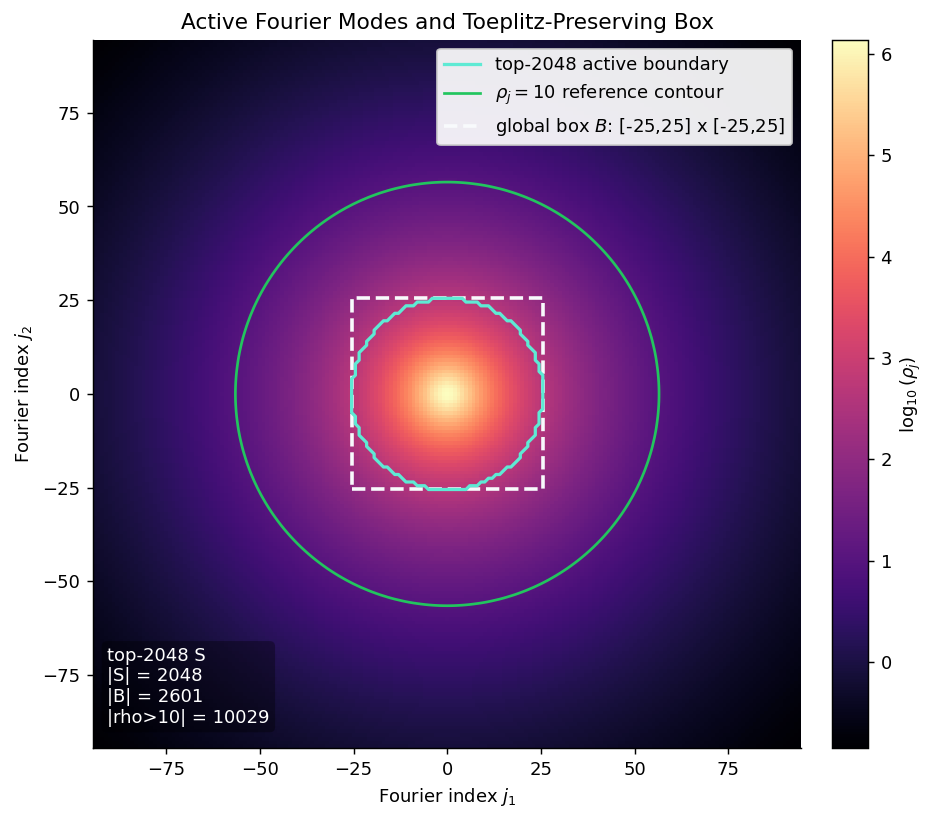

Figure 2: radial rho profile and cumulative Fourier spectral mass
  box Euclidean radius: 35.36
  cumulative rho mass at B: 0.9937
  cumulative |D|^2 mass at B: 0.9937 (same normalized mass because rho_j is proportional to |D_j|^2)
  radius where median radial rho ~= 10: ||j|| = 56.06
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\rho_radial_mass_profile.png
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\rho_radial_mass_profile.pdf


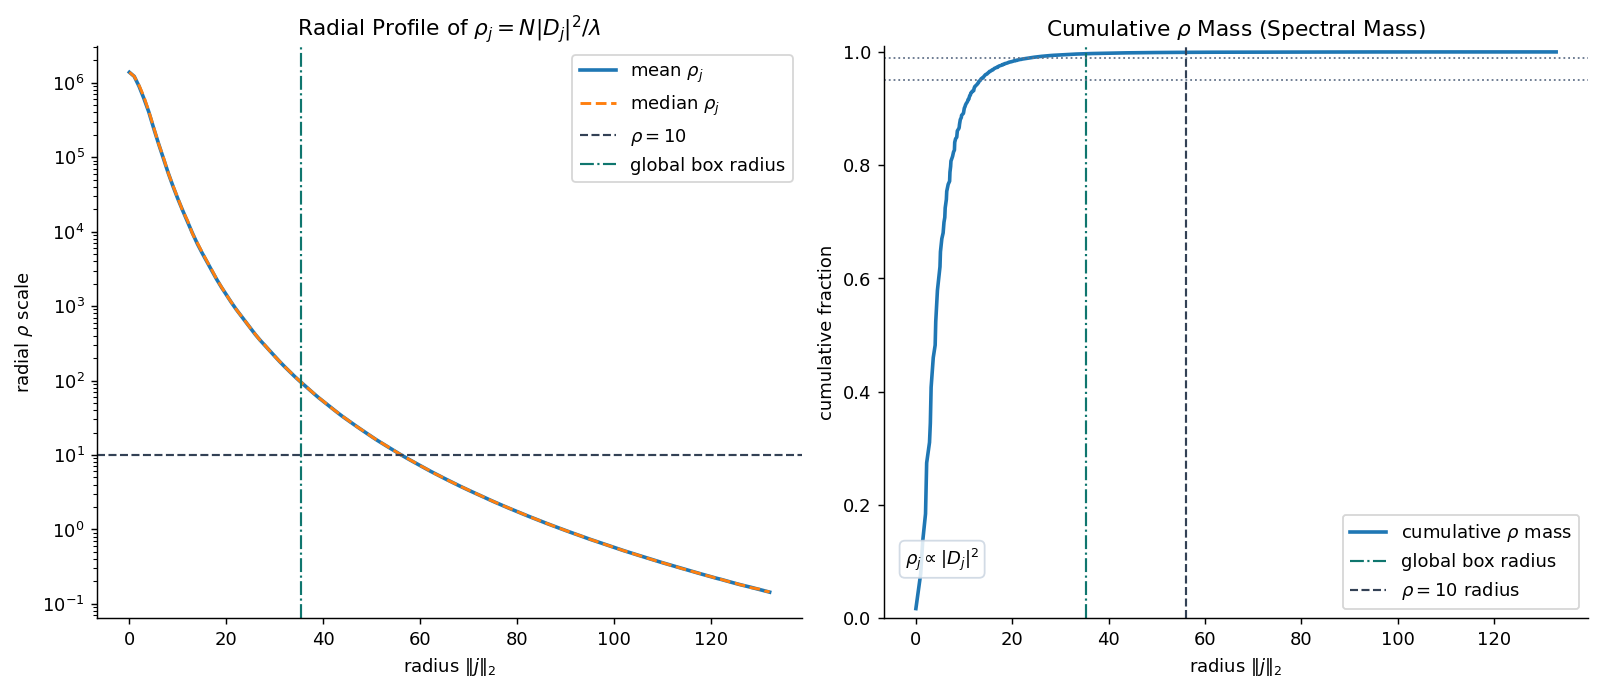

(WindowsPath('D:/NU/ML/efgp_eigenpro_py/gpu/box_toeplitz_active_block/picture/rho_radial_mass_profile.png'),
 WindowsPath('D:/NU/ML/efgp_eigenpro_py/gpu/box_toeplitz_active_block/picture/rho_radial_mass_profile.pdf'))

In [77]:
def safe_log10(values: np.ndarray, floor: float = 1e-300) -> np.ndarray:
    arr = np.asarray(values)
    return np.log10(np.maximum(np.abs(arr), float(floor)))


def save_figure(fig: plt.Figure, basename: str) -> tuple[Path, Path]:
    import os
    import time

    def _atomic_save(path: Path, **kwargs) -> Path:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        tmp_path = path.with_name(f"{path.stem}.tmp_{os.getpid()}_{time.time_ns()}{path.suffix}")
        fig.savefig(str(tmp_path), **kwargs)
        try:
            os.replace(str(tmp_path), str(path))
            return path
        except OSError as exc:
            fallback = path.with_name(f"{path.stem}.{time.strftime('%Y%m%d_%H%M%S')}{path.suffix}")
            os.replace(str(tmp_path), str(fallback))
            print(f"could not replace {path}: {exc}; saved fallback {fallback}")
            return fallback

    png_path = _atomic_save(PICTURE_DIR / f"{basename}.png", dpi=220, bbox_inches="tight")
    pdf_path = _atomic_save(PICTURE_DIR / f"{basename}.pdf", bbox_inches="tight")
    for path in (png_path, pdf_path):
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Figure was not written correctly: {path}")
    print(f"saved {png_path}")
    print(f"saved {pdf_path}")
    return png_path, pdf_path


def show_and_save_figure(fig: plt.Figure, basename: str) -> tuple[Path, Path]:
    from IPython.display import display

    paths = save_figure(fig, basename)
    display(fig)
    plt.close(fig)
    return paths


def radial_binned_stat(radius: np.ndarray, values: np.ndarray, *, reducer="mean") -> tuple[np.ndarray, np.ndarray]:
    radius = np.asarray(radius, dtype=np.float64).reshape(-1)
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    bins = np.floor(radius).astype(np.int64)
    out_r = []
    out_v = []
    for b in range(int(bins.max()) + 1):
        mask = bins == b
        if not np.any(mask):
            continue
        out_r.append(float(b))
        vals = values[mask]
        if reducer == "median":
            out_v.append(float(np.median(vals)))
        elif reducer == "max":
            out_v.append(float(np.max(vals)))
        else:
            out_v.append(float(np.mean(vals)))
    return np.asarray(out_r), np.asarray(out_v)


def cumulative_mass_by_radius(radius: np.ndarray, mass: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    radius = np.asarray(radius, dtype=np.float64).reshape(-1)
    mass = np.asarray(mass, dtype=np.float64).reshape(-1)
    order = np.argsort(radius)
    r_sorted = radius[order]
    m_sorted = np.maximum(mass[order], 0.0)
    cdf = np.cumsum(m_sorted) / max(float(np.sum(m_sorted)), 1e-300)
    keep = np.r_[np.diff(r_sorted) > 0, True]
    return r_sorted[keep], cdf[keep]


def reference_radius_from_radial_profile(
    radii: np.ndarray,
    values: np.ndarray,
    reference_level: float,
) -> float:
    radii = np.asarray(radii, dtype=np.float64).reshape(-1)
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    mask = np.isfinite(radii) & np.isfinite(values) & (values > 0.0)
    if not np.any(mask) or not np.isfinite(reference_level) or reference_level <= 0.0:
        return float("nan")

    r = radii[mask]
    log_values = np.log(values[mask])
    log_ref = float(np.log(reference_level))
    delta = log_values - log_ref

    crossing = np.flatnonzero(delta[:-1] * delta[1:] <= 0.0)
    if crossing.size:
        idx = int(crossing[0])
        if delta[idx] == 0.0:
            return float(r[idx])
        if delta[idx + 1] == 0.0:
            return float(r[idx + 1])
        t = -delta[idx] / (delta[idx + 1] - delta[idx])
        return float(r[idx] + t * (r[idx + 1] - r[idx]))

    return float(r[int(np.argmin(np.abs(delta)))])


plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 10,
})

if COLOR_FIELD == "rho":
    color_values = safe_log10(rho_grid)
    color_label = r"$\log_{10}(\rho_j)$"
elif COLOR_FIELD == "D_abs":
    color_values = safe_log10(D_abs_grid)
    color_label = r"$\log_{10}(|D_{jj}|)$"
else:
    raise ValueError(f"Unsupported COLOR_FIELD={COLOR_FIELD!r}")

active_mask = np.zeros((grid.mtot, grid.mtot), dtype=float)
active_mask.reshape(-1)[active.active_idx] = 1.0
r1, r2 = int(box_radii[0]), int(box_radii[1])
box_size = int(active.box_idx.size)
active_size = int(active.active_idx.size)
overhead = box_size / max(float(active_size), 1.0)
box_radius = float(np.linalg.norm(box_radii.astype(float)))
radius_grid = np.sqrt(J1.astype(float) ** 2 + J2.astype(float) ** 2)
rho_inside_box = float(np.sum(rho_grid.reshape(-1)[active.box_idx]) / max(np.sum(rho_grid), 1e-300))
d2_inside_box = float(np.sum((D_abs_grid.reshape(-1)[active.box_idx] ** 2)) / max(np.sum(D_abs_grid ** 2), 1e-300))
rho_reference_level = float(RHO_REFERENCE_LEVEL)
rho_reference_label = f"{rho_reference_level:g}"
tau_reference_size = int(np.sum(rho_grid > rho_reference_level))
rho_reference_visible = float(np.nanmin(rho_grid)) <= rho_reference_level <= float(np.nanmax(rho_grid))

print("Figure 1: signal-to-regularization profile and Toeplitz-preserving active box")
print(f"  active mode: {ACTIVE_MODE}; active modes |S|: {active_size}")
print(f"  |{{j: rho_j > {rho_reference_label}}}|: {tau_reference_size}")
print(f"  box size |B|: {box_size}")
print(f"  overhead |B|/|S|: {overhead:.3f}")
print(f"  rho mass inside B: {rho_inside_box:.4f}; |D|^2 mass inside B: {d2_inside_box:.4f}")
print(f"  rho={rho_reference_label} contour visible: {rho_reference_visible}")
print(f"  note: rho={rho_reference_label} is a reference contour; the active set is selected by top-k.")

fig, ax = plt.subplots(figsize=(7.0, 6.2), constrained_layout=True)
mesh = ax.pcolormesh(J1, J2, color_values, shading="auto", cmap="magma")
cb = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cb.set_label(color_label)
ax.contour(J1, J2, active_mask, levels=[0.5], colors=["#5eead4"], linewidths=1.8)
if rho_reference_visible:
    ax.contour(J1, J2, rho_grid, levels=[rho_reference_level], colors=["#22c55e"], linewidths=1.5, linestyles="-")
box_patch = Rectangle(
    (-r1 - 0.5, -r2 - 0.5),
    2 * r1 + 1,
    2 * r2 + 1,
    fill=False,
    edgecolor="#f8fafc",
    linewidth=2.0,
    linestyle="--",
)
ax.add_patch(box_patch)
ax.text(
    0.02,
    0.03,
    f"top-{int(ACTIVE_TOPK)} S\n|S| = {active_size}\n|B| = {box_size}\n|rho>{rho_reference_label}| = {tau_reference_size}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    color="white",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "black", "alpha": 0.35, "edgecolor": "none"},
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"Fourier index $j_1$")
ax.set_ylabel(r"Fourier index $j_2$")
ax.set_title("Active Fourier Modes and Toeplitz-Preserving Box")
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color="#5eead4", lw=1.8, label=f"top-{int(ACTIVE_TOPK)} active boundary"),
    Line2D([0], [0], color="#22c55e", lw=1.5, label=rf"$\rho_j = {rho_reference_label}$ reference contour"),
    Line2D([0], [0], color="#f8fafc", lw=2.0, linestyle="--", label=rf"global box $B$: [{-r1},{r1}] x [{-r2},{r2}]"),
]
if not rho_reference_visible:
    handles.pop(1)
ax.legend(handles=handles, loc="upper right", frameon=True, framealpha=0.92)
show_and_save_figure(fig, OUTPUT_BASENAME_ACTIVE)

print("Figure 2: radial rho profile and cumulative Fourier spectral mass")
r_mean, rho_mean = radial_binned_stat(radius_grid, rho_grid, reducer="mean")
r_med, rho_med = radial_binned_stat(radius_grid, rho_grid, reducer="median")
r_cdf_rho, cdf_rho = cumulative_mass_by_radius(radius_grid, rho_grid)
rho_reference_radius = reference_radius_from_radial_profile(r_med, rho_med, rho_reference_level)
print(f"  box Euclidean radius: {box_radius:.2f}")
print(f"  cumulative rho mass at B: {rho_inside_box:.4f}")
print(f"  cumulative |D|^2 mass at B: {d2_inside_box:.4f} (same normalized mass because rho_j is proportional to |D_j|^2)")
if np.isfinite(rho_reference_radius):
    print(f"  radius where median radial rho ~= {rho_reference_label}: ||j|| = {rho_reference_radius:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2), constrained_layout=True)
axes[0].plot(r_mean, rho_mean, lw=2.0, label=r"mean $\rho_j$")
axes[0].plot(r_med, rho_med, lw=1.6, linestyle="--", label=r"median $\rho_j$")
axes[0].axhline(rho_reference_level, color="#334155", lw=1.2, linestyle="--", label=rf"$\rho={rho_reference_label}$")
axes[0].axvline(box_radius, color="#0f766e", lw=1.2, linestyle="-.", label=r"global box radius")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"radius $\|j\|_2$")
axes[0].set_ylabel(r"radial $\rho$ scale")
axes[0].set_title(r"Radial Profile of $\rho_j = N|D_j|^2/\lambda$")
axes[0].legend(frameon=True)

axes[1].plot(r_cdf_rho, cdf_rho, lw=2.0, label=r"cumulative $\rho$ mass")
axes[1].axvline(box_radius, color="#0f766e", lw=1.2, linestyle="-.", label=r"global box radius")
if np.isfinite(rho_reference_radius):
    axes[1].axvline(rho_reference_radius, color="#334155", lw=1.2, linestyle="--", label=rf"$\rho={rho_reference_label}$ radius")
axes[1].axhline(0.95, color="#64748b", lw=1.0, linestyle=":")
axes[1].axhline(0.99, color="#64748b", lw=1.0, linestyle=":")
axes[1].set_ylim(0.0, 1.01)
axes[1].set_xlabel(r"radius $\|j\|_2$")
axes[1].set_ylabel("cumulative fraction")
axes[1].set_title(r"Cumulative $\rho$ Mass (Spectral Mass)")
axes[1].text(
    0.03,
    0.08,
    r"$\rho_j \propto |D_j|^2$",
    transform=axes[1].transAxes,
    ha="left",
    va="bottom",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "#cbd5e1"},
)
axes[1].legend(frameon=True, loc="lower right")

show_and_save_figure(fig, OUTPUT_BASENAME_DECAY)


## Dense Toy Matrix Intuition Figures
The full Fourier system can be too large for dense matrix plots, so this section extracts a centered toy Fourier window and builds a smaller toy active box inside it. This toy box is distinct from the global active box above. The block heatmap is scaled by the regularization level and plots the signal part `H = A - lambda I`; it is a signal-concentration diagnostic, not a strict tail diagonal-dominance claim.


In [78]:
def centered_window_indices(full_mtot: int, toy_hm: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    center = (int(full_mtot) - 1) // 2
    toy_j = np.arange(-int(toy_hm), int(toy_hm) + 1, dtype=np.int64)
    I1, I2 = np.meshgrid(center + toy_j, center + toy_j, indexing="ij")
    full_flat = np.ravel_multi_index((I1.reshape(-1), I2.reshape(-1)), dims=(int(full_mtot), int(full_mtot)))
    M1, M2 = np.meshgrid(toy_j, toy_j, indexing="ij")
    modes = np.stack([M1.reshape(-1), M2.reshape(-1)], axis=1)
    return full_flat.astype(np.int64), modes.astype(np.int64), toy_j


def dense_A_from_toeplitz(weights_sub: np.ndarray, modes: np.ndarray, xtxcol: np.ndarray, reg_lambda: float, mtot: int) -> np.ndarray:
    modes = np.asarray(modes, dtype=np.int64)
    lag_center = int(mtot) - 1
    diff0 = modes[:, 0][:, None] - modes[:, 0][None, :]
    diff1 = modes[:, 1][:, None] - modes[:, 1][None, :]
    Gij = xtxcol[lag_center + diff0, lag_center + diff1]
    A = weights_sub[:, None] * Gij * weights_sub[None, :]
    A = A + float(reg_lambda) * np.eye(int(weights_sub.size), dtype=np.complex128)
    return 0.5 * (A + A.conj().T)


def subset_for_heatmap(n: int, max_size: int, *, keep_prefix: int = 0, min_tail_fraction: float = 1.0 / 3.0) -> np.ndarray:
    n = int(n)
    max_size = max(8, int(max_size))
    keep_prefix = max(0, min(int(keep_prefix), n))
    if n <= max_size:
        return np.arange(n, dtype=np.int64)
    if keep_prefix <= 0 or keep_prefix >= n:
        return np.unique(np.linspace(0, n - 1, max_size, dtype=np.int64)).astype(np.int64)

    tail_total = n - keep_prefix
    min_tail = min(tail_total, max(64, int(round(max_size * float(min_tail_fraction)))))
    prefix_budget = max(1, max_size - min_tail)
    tail_budget = max(1, max_size - prefix_budget)

    if keep_prefix <= prefix_budget:
        prefix = np.arange(keep_prefix, dtype=np.int64)
        tail_budget = max(1, max_size - prefix.size)
    else:
        prefix = np.unique(np.linspace(0, keep_prefix - 1, prefix_budget, dtype=np.int64)).astype(np.int64)

    tail = np.unique(np.linspace(keep_prefix, n - 1, min(tail_budget, tail_total), dtype=np.int64)).astype(np.int64)
    return np.unique(np.concatenate([prefix, tail])).astype(np.int64)


toy_hm = int(MATRIX_TOY_HM)
if toy_hm < 2 or 2 * toy_hm + 1 > int(grid.mtot):
    raise ValueError(f"MATRIX_TOY_HM={toy_hm} must satisfy 2 <= hm and 2*hm+1 <= mtot={grid.mtot}.")

full_flat, toy_modes, toy_j = centered_window_indices(int(grid.mtot), toy_hm)
weights_toy = np.ascontiguousarray(weights_flat[full_flat])
rhs_toy = np.ascontiguousarray(rhs_flat[full_flat])
toy_mtot = 2 * toy_hm + 1
toy_total_modes = int(weights_toy.size)
max_matrix_topk = toy_total_modes - 1
if int(MATRIX_ACTIVE_TOPK) >= toy_total_modes:
    raise ValueError(
        "MATRIX_ACTIVE_TOPK is too large for the dense toy Fourier window. "
        f"With MATRIX_TOY_HM={toy_hm}, the toy grid has only (2*hm+1)^2 = {toy_total_modes} modes, "
        f"so MATRIX_ACTIVE_TOPK must be <= {max_matrix_topk} to leave a non-empty tail block. "
        "Increase MATRIX_TOY_HM or decrease MATRIX_ACTIVE_TOPK."
    )

toy_active = build_box_active_set(
    gamma=float(gamma),
    weights=weights_toy,
    reg_lambda=float(REG_LAMBDA),
    mtot=int(toy_mtot),
    dim=2,
    active_mode="topk",
    active_topk=int(MATRIX_ACTIVE_TOPK),
    active_tau=None,
    box_budget=None,
)
toy_B_idx = np.asarray(toy_active.box_idx, dtype=np.int64)
toy_T_idx = np.asarray(toy_active.tail_idx, dtype=np.int64)
toy_order_BT = np.concatenate([toy_B_idx, toy_T_idx])
toy_nB = int(toy_B_idx.size)
toy_nT = int(toy_T_idx.size)

A_toy = dense_A_from_toeplitz(weights_toy, toy_modes, XtXcol, float(REG_LAMBDA), int(grid.mtot))
A_ord = A_toy[np.ix_(toy_order_BT, toy_order_BT)]
b_ord = rhs_toy[toy_order_BT]
diag_ord = np.maximum(np.real(np.diag(A_ord)), 1e-300)
ABB = A_ord[:toy_nB, :toy_nB]
ATT = A_ord[toy_nB:, toy_nB:]

print("Dense toy matrix for block/preconditioning figures")
print("-" * 80)
print(f"global Fourier grid M: {weights_flat.size}; global active |S|: {active_size}; global box |B|: {box_size}")
print(f"toy Fourier window hm: {toy_hm}; toy M: {A_toy.shape[0]} ({toy_mtot} x {toy_mtot})")
print(f"toy active top-k: {MATRIX_ACTIVE_TOPK}; toy box |B_toy|: {toy_nB}; toy tail |T_toy|: {toy_nT}")
print(f"toy box radii: {np.asarray(toy_active.radii, dtype=int).tolist()}")
print("  note: dense figures use this centered toy window and its smaller toy active box, not the global box above.")
print(f"A_toy Hermitian relative error: {np.linalg.norm(A_toy - A_toy.conj().T) / max(np.linalg.norm(A_toy), 1e-300):.3e}")
print(f"real toy RHS ||b||_2: {np.linalg.norm(b_ord):.6e}")
print(f"real toy RHS energy in B_toy: {float(np.sum(np.abs(b_ord[:toy_nB])**2) / max(np.sum(np.abs(b_ord)**2), 1e-300)):.4f}")


Dense toy matrix for block/preconditioning figures
--------------------------------------------------------------------------------
global Fourier grid M: 35721; global active |S|: 2048; global box |B|: 2601
toy Fourier window hm: 30; toy M: 3721 (61 x 61)
toy active top-k: 1024; toy box |B_toy|: 1369; toy tail |T_toy|: 2352
toy box radii: [18, 18]
  note: dense figures use this centered toy window and its smaller toy active box, not the global box above.
A_toy Hermitian relative error: 0.000e+00
real toy RHS ||b||_2: 1.327232e+06
real toy RHS energy in B_toy: 1.0000


Figure 3: signal block concentration in the dense toy window
  plotting log10(|H_ij| / lambda), H = A - lambda I; toy block split at |B_toy|=1369
  displayed block samples: B_toy=1200, T_toy=600, total=1800
  mean |H_ij|/lambda by toy block: {'B_toy B_toy': 492.8147120496194, 'B_toy T_toy': 6.169442407840748, 'T_toy B_toy': 6.169442407840747, 'T_toy T_toy': 2.280636703543395}
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\matrix_block_structure.png
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\matrix_block_structure.pdf


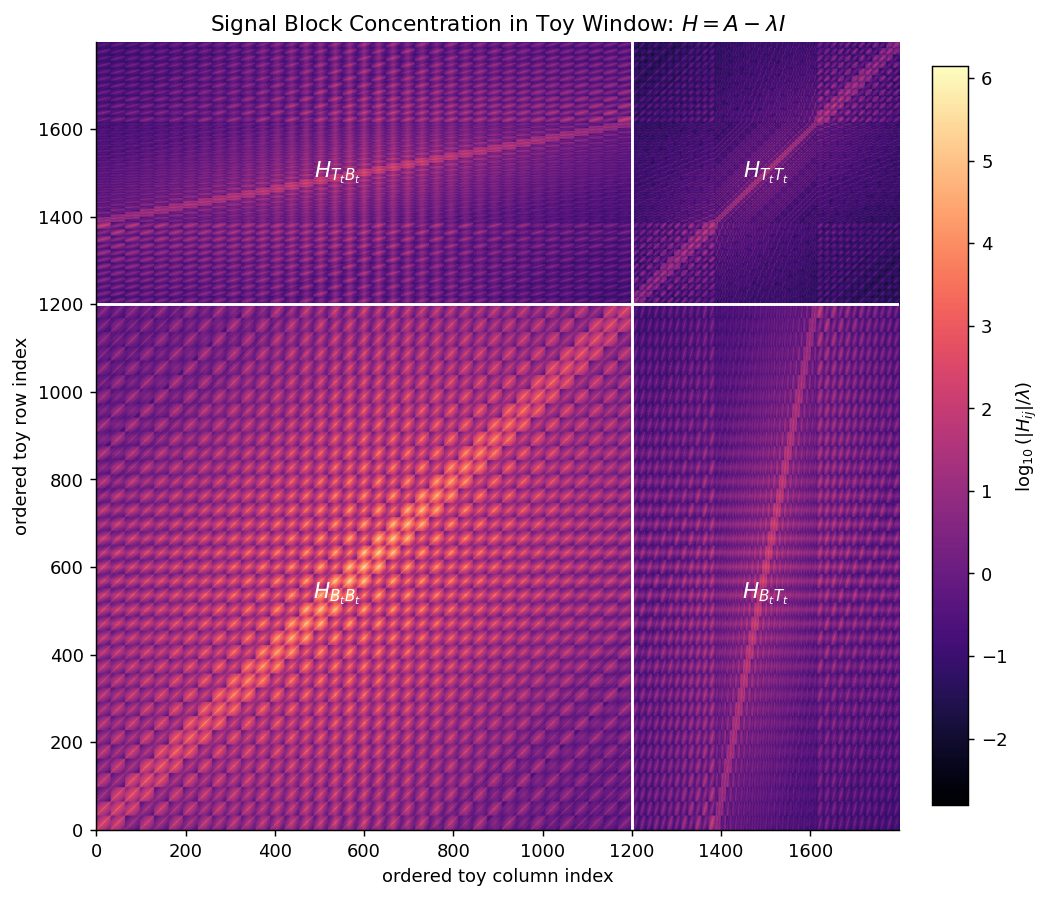

In [79]:
print("Figure 3: signal block concentration in the dense toy window")
print(f"  plotting log10(|H_ij| / lambda), H = A - lambda I; toy block split at |B_toy|={toy_nB}")
H_ord = A_ord - float(REG_LAMBDA) * np.eye(A_ord.shape[0], dtype=np.complex128)
H_scaled = np.abs(H_ord) / max(float(REG_LAMBDA), 1e-300)
plot_idx = subset_for_heatmap(H_scaled.shape[0], int(MATRIX_MAX_HEATMAP_SIZE), keep_prefix=toy_nB)
H_plot = H_scaled[np.ix_(plot_idx, plot_idx)]
toy_nB_display = int(np.searchsorted(plot_idx, toy_nB))
toy_nT_display = int(H_plot.shape[0] - toy_nB_display)
line_pos = toy_nB_display - 0.5
print(f"  displayed block samples: B_toy={toy_nB_display}, T_toy={toy_nT_display}, total={H_plot.shape[0]}")

block_means = {
    "B_toy B_toy": float(np.mean(H_scaled[:toy_nB, :toy_nB])),
    "B_toy T_toy": float(np.mean(H_scaled[:toy_nB, toy_nB:])),
    "T_toy B_toy": float(np.mean(H_scaled[toy_nB:, :toy_nB])),
    "T_toy T_toy": float(np.mean(H_scaled[toy_nB:, toy_nB:])),
}
print("  mean |H_ij|/lambda by toy block:", block_means)

fig, ax = plt.subplots(figsize=(8.0, 6.8), constrained_layout=True)
im = ax.imshow(safe_log10(H_plot), origin="lower", cmap="magma", aspect="auto")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"$\log_{10}(|H_{ij}|/\lambda)$")
if 0 < line_pos < H_plot.shape[0]:
    ax.axhline(line_pos, color="white", lw=1.6)
    ax.axvline(line_pos, color="white", lw=1.6)
    ax.text(max(line_pos * 0.45, 1), max(line_pos * 0.45, 1), r"$H_{B_tB_t}$", color="white", ha="center", va="center", fontsize=12)
    ax.text(line_pos + (H_plot.shape[0] - line_pos) * 0.5, max(line_pos * 0.45, 1), r"$H_{B_tT_t}$", color="white", ha="center", va="center", fontsize=12)
    ax.text(max(line_pos * 0.45, 1), line_pos + (H_plot.shape[0] - line_pos) * 0.5, r"$H_{T_tB_t}$", color="white", ha="center", va="center", fontsize=12)
    ax.text(line_pos + (H_plot.shape[0] - line_pos) * 0.5, line_pos + (H_plot.shape[0] - line_pos) * 0.5, r"$H_{T_tT_t}$", color="white", ha="center", va="center", fontsize=12)
ax.set_title(r"Signal Block Concentration in Toy Window: $H = A - \lambda I$")
ax.set_xlabel("ordered toy column index")
ax.set_ylabel("ordered toy row index")
save_figure(fig, OUTPUT_BASENAME_BLOCKS)
plt.show()


Figure 4: normalized tail coupling distribution in the dense toy window
  C_T shape: (2352, 2352)
  median |offdiag(C_T)|: 5.658e-04
  90% quantile |offdiag(C_T)|: 7.181e-03
  99% quantile |offdiag(C_T)|: 7.983e-02
  max |offdiag(C_T)|: 6.128e-01
  diagonal range: [1.000000, 1.000000]
  note: most normalized tail off-diagonal couplings are small; this is not a strict diagonal-dominance claim.
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\normalized_tail_couplings.png
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\normalized_tail_couplings.pdf


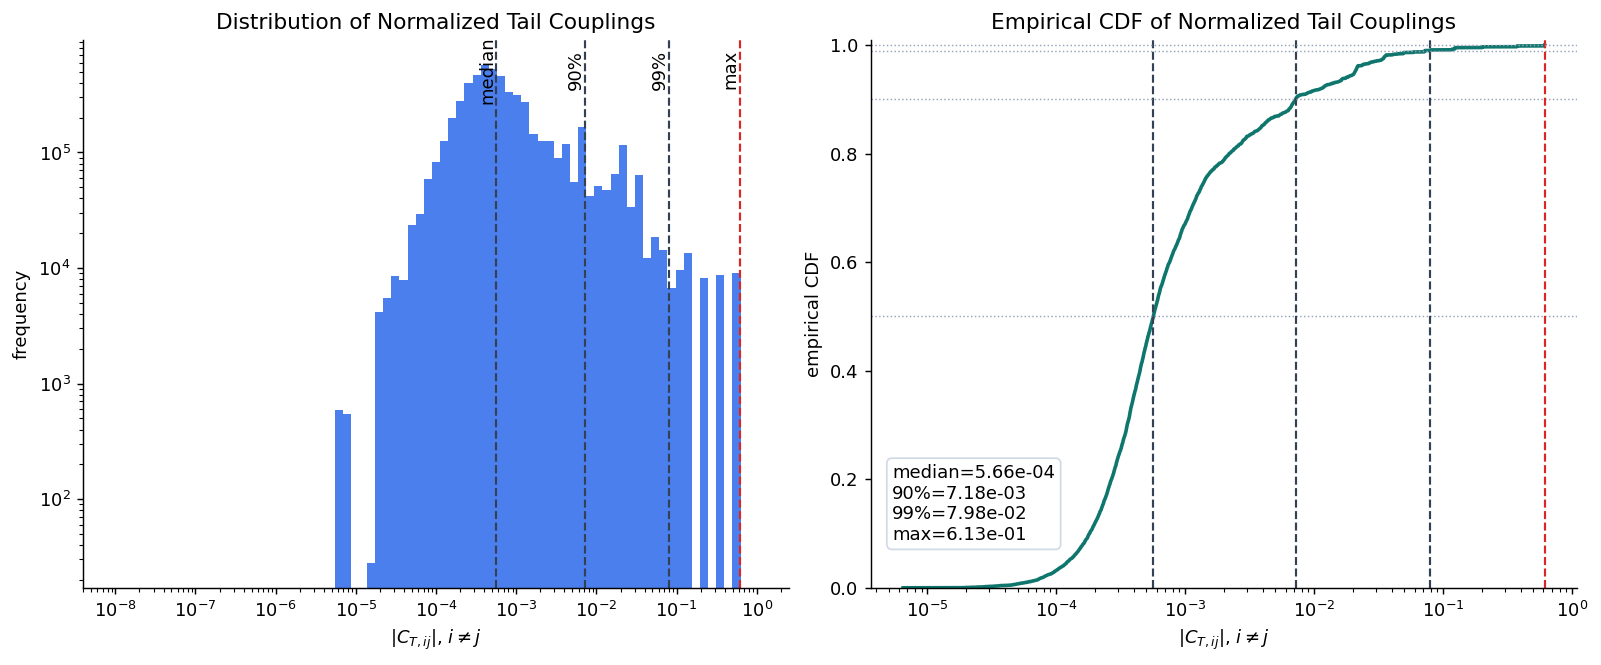

(WindowsPath('D:/NU/ML/efgp_eigenpro_py/gpu/box_toeplitz_active_block/picture/normalized_tail_couplings.png'),
 WindowsPath('D:/NU/ML/efgp_eigenpro_py/gpu/box_toeplitz_active_block/picture/normalized_tail_couplings.pdf'))

In [80]:
print("Figure 4: normalized tail coupling distribution in the dense toy window")
tail_diag = np.maximum(np.real(np.diag(ATT)), 1e-300)
if ATT.shape[0] < 2:
    print(f"  C_T shape: {ATT.shape}")
    print("  tail block has fewer than 2 modes, so there are no off-diagonal tail couplings to summarize.")
    print("  Increase MATRIX_TOY_HM or decrease MATRIX_ACTIVE_TOPK if you need a non-empty tail-coupling distribution.")
    fig, ax = plt.subplots(figsize=(7.8, 4.8), constrained_layout=True)
    ax.axis("off")
    ax.text(
        0.5,
        0.55,
        "No off-diagonal tail couplings",
        ha="center",
        va="center",
        fontsize=15,
        weight="bold",
        transform=ax.transAxes,
    )
    ax.text(
        0.5,
        0.40,
        f"tail block size = {ATT.shape[0]}\nIncrease MATRIX_TOY_HM or decrease MATRIX_ACTIVE_TOPK",
        ha="center",
        va="center",
        fontsize=11,
        transform=ax.transAxes,
    )
else:
    inv_sqrt_tail = 1.0 / np.sqrt(tail_diag)
    C_T = inv_sqrt_tail[:, None] * ATT * inv_sqrt_tail[None, :]
    C_T = 0.5 * (C_T + C_T.conj().T)
    offdiag_mask = ~np.eye(C_T.shape[0], dtype=bool)
    offdiag_vals = np.abs(C_T[offdiag_mask])
    quantiles = np.quantile(offdiag_vals, [0.5, 0.9, 0.99])
    max_offdiag = float(np.max(offdiag_vals))
    print(f"  C_T shape: {C_T.shape}")
    print(f"  median |offdiag(C_T)|: {quantiles[0]:.3e}")
    print(f"  90% quantile |offdiag(C_T)|: {quantiles[1]:.3e}")
    print(f"  99% quantile |offdiag(C_T)|: {quantiles[2]:.3e}")
    print(f"  max |offdiag(C_T)|: {max_offdiag:.3e}")
    print(f"  diagonal range: [{np.min(np.real(np.diag(C_T))):.6f}, {np.max(np.real(np.diag(C_T))):.6f}]")
    print("  note: most normalized tail off-diagonal couplings are small; this is not a strict diagonal-dominance claim.")

    vals_sorted = np.sort(offdiag_vals)
    y_cdf = np.arange(1, vals_sorted.size + 1, dtype=np.float64) / float(vals_sorted.size)
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.0), constrained_layout=True)
    axes[0].hist(offdiag_vals, bins=np.logspace(-8, 0, 80), color="#2563eb", alpha=0.82)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(r"$|C_{T,ij}|$, $i \neq j$")
    axes[0].set_ylabel("frequency")
    axes[0].set_title("Distribution of Normalized Tail Couplings")
    for value, label in [(quantiles[0], "median"), (quantiles[1], "90%"), (quantiles[2], "99%"), (max_offdiag, "max")]:
        axes[0].axvline(value, color="#dc2626" if label == "max" else "#334155", lw=1.2, linestyle="--")
        axes[0].text(value, axes[0].get_ylim()[1] * 0.55, label, rotation=90, va="center", ha="right")

    axes[1].plot(vals_sorted, y_cdf, color="#0f766e", lw=2.0)
    axes[1].set_xscale("log")
    axes[1].set_ylim(0.0, 1.01)
    axes[1].set_xlabel(r"$|C_{T,ij}|$, $i \neq j$")
    axes[1].set_ylabel("empirical CDF")
    axes[1].set_title("Empirical CDF of Normalized Tail Couplings")
    for value, label, y in [(quantiles[0], "median", 0.5), (quantiles[1], "90%", 0.9), (quantiles[2], "99%", 0.99), (max_offdiag, "max", 1.0)]:
        axes[1].axvline(value, color="#dc2626" if label == "max" else "#334155", lw=1.2, linestyle="--")
        axes[1].axhline(y, color="#94a3b8", lw=0.8, linestyle=":")
    axes[1].text(0.03, 0.08, f"median={quantiles[0]:.2e}\n90%={quantiles[1]:.2e}\n99%={quantiles[2]:.2e}\nmax={max_offdiag:.2e}", transform=axes[1].transAxes, ha="left", va="bottom", bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "#cbd5e1"})

show_and_save_figure(fig, OUTPUT_BASENAME_TAIL)


Figure 5: preconditioning spectra
  Combined spectra: raw A, active inverse, and largest-q EigenPro-Type active inverse.
  A                            cond approx: 4.569e+06; eig range [1.000e-01, 4.569e+05]
  active inverse |B|=1369      cond approx: 9.811e+03; eig range [4.655e-04, 4.567e+00]
  EigenPro-Type q=256          cond approx: 4.623e+04; eig range [8.172e-05, 3.778e+00]
  EigenPro-Type q-sweep for appendix diagnostics:
    q=  8: cond approx 8.029e+06
    q= 16: cond approx 5.499e+06
    q= 32: cond approx 2.379e+06
    q= 64: cond approx 7.783e+05
    q= 96: cond approx 3.915e+05
    q=128: cond approx 2.139e+05
    q=160: cond approx 1.329e+05
    q=256: cond approx 4.623e+04
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\preconditioning_effect_spectrum.png
saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\preconditioning_effect_spectrum.pdf


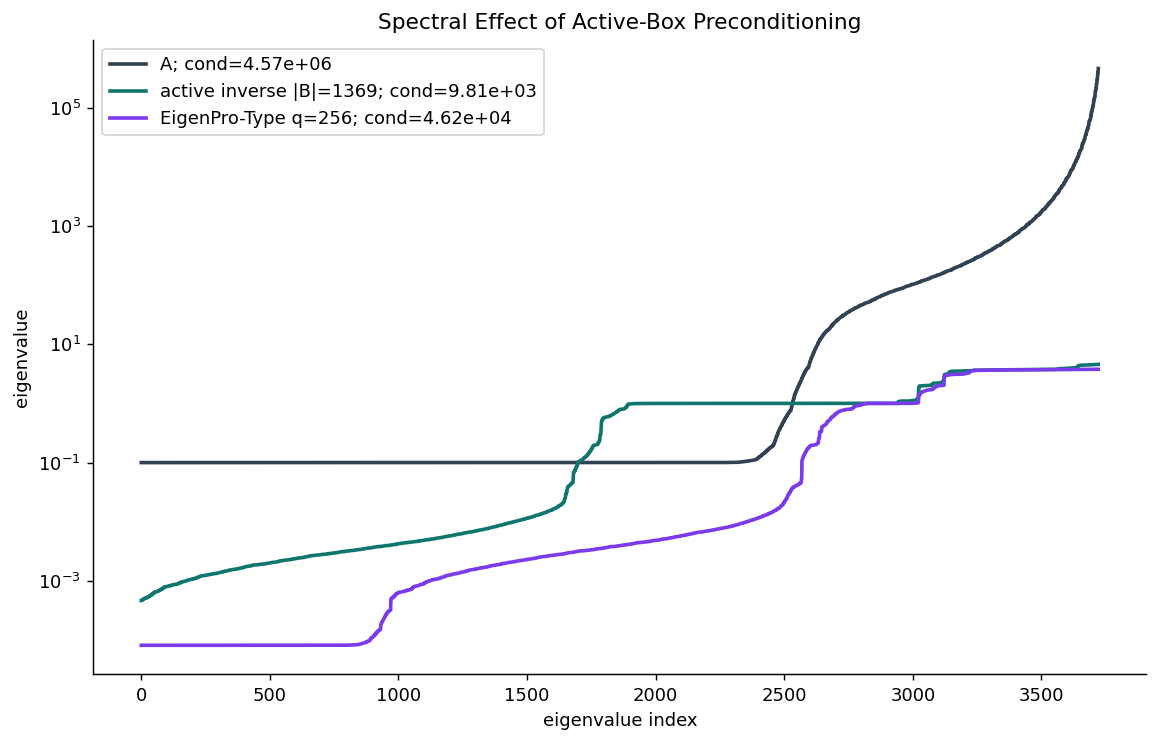

(WindowsPath('D:/NU/ML/efgp_eigenpro_py/gpu/box_toeplitz_active_block/picture/preconditioning_effect_spectrum.png'),
 WindowsPath('D:/NU/ML/efgp_eigenpro_py/gpu/box_toeplitz_active_block/picture/preconditioning_effect_spectrum.pdf'))

In [81]:
def invsqrt_from_spd(M: np.ndarray, floor: float = 1e-12) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    vals, vecs = np.linalg.eigh(0.5 * (M + M.conj().T))
    vals = np.maximum(np.real(vals), float(floor))
    inv = (vecs * (1.0 / vals)[None, :]) @ vecs.conj().T
    invsqrt = (vecs * (1.0 / np.sqrt(vals))[None, :]) @ vecs.conj().T
    sqrt = (vecs * np.sqrt(vals)[None, :]) @ vecs.conj().T
    return inv, invsqrt, sqrt


def block_diag_sandwich(PB_sqrt: np.ndarray, tail_sqrt_diag: np.ndarray, A: np.ndarray, split: int) -> np.ndarray:
    split = int(split)
    S = np.empty_like(A)
    S[:split, :split] = PB_sqrt @ A[:split, :split] @ PB_sqrt
    S[:split, split:] = PB_sqrt @ A[:split, split:] * tail_sqrt_diag[None, :]
    S[split:, :split] = tail_sqrt_diag[:, None] * (A[split:, :split] @ PB_sqrt)
    S[split:, split:] = tail_sqrt_diag[:, None] * A[split:, split:] * tail_sqrt_diag[None, :]
    return 0.5 * (S + S.conj().T)


def condition_number(vals: np.ndarray) -> float:
    vals_pos = np.maximum(np.real(vals), 1e-300)
    return float(vals_pos[-1] / vals_pos[0])


print("Figure 5: preconditioning spectra")
print("  Combined spectra: raw A, active inverse, and largest-q EigenPro-Type active inverse.")
ABB_inv, ABB_inv_sqrt, _ = invsqrt_from_spd(ABB)

vals_B, vecs_B = np.linalg.eigh(0.5 * (ABB + ABB.conj().T))
order_desc = np.argsort(np.real(vals_B))[::-1]
vals_B = np.real(vals_B[order_desc])
vecs_B = vecs_B[:, order_desc]

max_q_allowed = max(1, toy_nB - 2)
valid_q_options = [int(q) for q in EIG_COMPRESSED_RANK_OPTIONS if 1 <= int(q) <= max_q_allowed]
q_largest = max(valid_q_options) if valid_q_options else min(max(1, int(EIG_COMPRESSED_RANK)), max_q_allowed)


def compressed_block_sqrt(q_rank: int) -> np.ndarray:
    q_rank = min(max(1, int(q_rank)), max_q_allowed)
    theta_top = np.maximum(vals_B[:q_rank], 1e-300)
    theta_q1 = float(max(vals_B[q_rank], 1e-300))
    Uq = vecs_B[:, :q_rank]
    alpha = 1.0 / theta_q1
    sqrt_alpha = math.sqrt(alpha)
    return sqrt_alpha * np.eye(toy_nB, dtype=np.complex128) + (Uq * ((1.0 / np.sqrt(theta_top)) - sqrt_alpha)[None, :]) @ Uq.conj().T


tail_inv_sqrt = 1.0 / np.sqrt(np.maximum(np.real(np.diag(A_ord))[toy_nB:], 1e-300))
S_A = A_ord
S_active = block_diag_sandwich(ABB_inv_sqrt, tail_inv_sqrt, A_ord, toy_nB)
S_eig_largest = block_diag_sandwich(compressed_block_sqrt(q_largest), tail_inv_sqrt, A_ord, toy_nB)

active_inverse_label = f"active inverse |B|={toy_nB}"
eigenpro_type_label = f"EigenPro-Type q={q_largest}"
spectra = {
    "A": np.linalg.eigvalsh(S_A),
    active_inverse_label: np.linalg.eigvalsh(S_active),
    eigenpro_type_label: np.linalg.eigvalsh(S_eig_largest),
}
for name, vals in spectra.items():
    vals_pos = np.maximum(np.real(vals), 1e-300)
    print(f"  {name:28s} cond approx: {vals_pos[-1] / vals_pos[0]:.3e}; eig range [{vals_pos[0]:.3e}, {vals_pos[-1]:.3e}]")

print("  EigenPro-Type q-sweep for appendix diagnostics:")
for q_opt in EIG_COMPRESSED_RANK_OPTIONS:
    if int(q_opt) > max_q_allowed:
        continue
    S_q = block_diag_sandwich(compressed_block_sqrt(q_opt), tail_inv_sqrt, A_ord, toy_nB)
    vals_q = np.linalg.eigvalsh(S_q)
    print(f"    q={int(q_opt):3d}: cond approx {condition_number(vals_q):.3e}")

fig, ax = plt.subplots(figsize=(8.8, 5.6), constrained_layout=True)
colors = {
    "A": "#334155",
    active_inverse_label: "#0f766e",
    eigenpro_type_label: "#7c3aed",
}
for name, vals in spectra.items():
    vals_pos = np.maximum(np.sort(np.real(vals)), 1e-300)
    cond = vals_pos[-1] / vals_pos[0]
    ax.plot(
        np.arange(1, vals_pos.size + 1),
        vals_pos,
        lw=2.0,
        color=colors[name],
        label=f"{name}; cond={cond:.2e}",
    )
ax.set_yscale("log")
ax.set_xlabel("eigenvalue index")
ax.set_ylabel("eigenvalue")
ax.set_title(r"Spectral Effect of Active-Box Preconditioning")
ax.legend(frameon=True)

show_and_save_figure(fig, OUTPUT_BASENAME_SPECTRUM)


## Required Refreshed Figure Outputs

These two cells regenerate the requested figures, save both PNG/PDF files, print the saved file timestamps, and display the freshly generated figures inline.


REQUIRED_REFRESH_FIGURE_OUTPUT: radial profile + cumulative mass
  refresh started: 2026-06-27T14:17:10
  saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\rho_radial_mass_profile.png | bytes=174256 | mtime=2026-06-27T14:17:12
  saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\rho_radial_mass_profile.pdf | bytes=24619 | mtime=2026-06-27T14:17:13
  cumulative rho mass at B: 0.9937
  cumulative |D|^2 mass at B: 0.9937
  radius where median radial rho ~= 10: ||j|| = 56.06


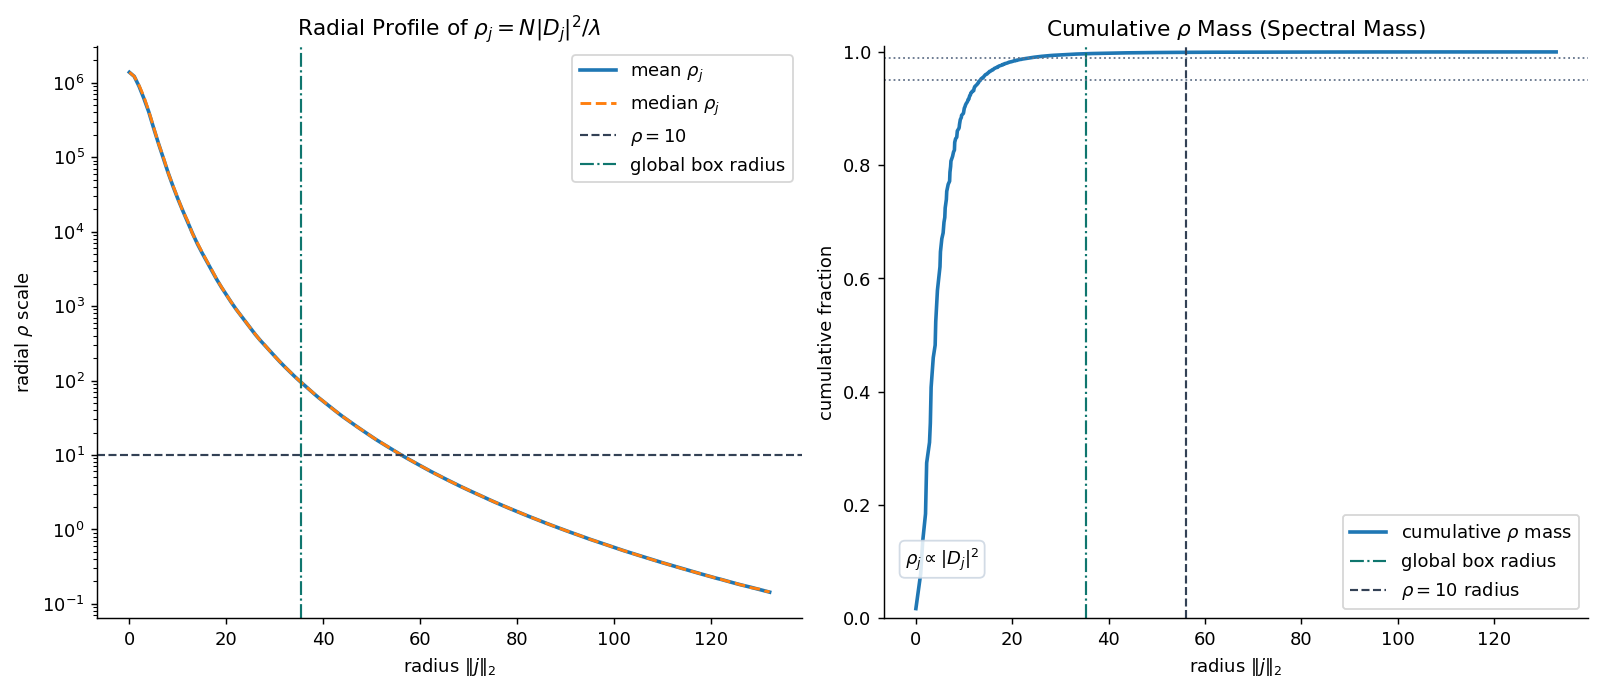

In [82]:
# REQUIRED_REFRESH_FIGURE_OUTPUT: radial profile + cumulative mass
from datetime import datetime
from IPython.display import display

print("REQUIRED_REFRESH_FIGURE_OUTPUT: radial profile + cumulative mass")
print(f"  refresh started: {datetime.now().isoformat(timespec='seconds')}")

r_mean, rho_mean = radial_binned_stat(radius_grid, rho_grid, reducer="mean")
r_med, rho_med = radial_binned_stat(radius_grid, rho_grid, reducer="median")
r_cdf_rho, cdf_rho = cumulative_mass_by_radius(radius_grid, rho_grid)
rho_reference_level = float(RHO_REFERENCE_LEVEL)
rho_reference_label = f"{rho_reference_level:g}"
rho_reference_radius = reference_radius_from_radial_profile(r_med, rho_med, rho_reference_level)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2), constrained_layout=True)
axes[0].plot(r_mean, rho_mean, lw=2.0, label=r"mean $\rho_j$")
axes[0].plot(r_med, rho_med, lw=1.6, linestyle="--", label=r"median $\rho_j$")
axes[0].axhline(rho_reference_level, color="#334155", lw=1.2, linestyle="--", label=rf"$\rho={rho_reference_label}$")
axes[0].axvline(box_radius, color="#0f766e", lw=1.2, linestyle="-.", label=r"global box radius")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"radius $\|j\|_2$")
axes[0].set_ylabel(r"radial $\rho$ scale")
axes[0].set_title(r"Radial Profile of $\rho_j = N|D_j|^2/\lambda$")
axes[0].legend(frameon=True)

axes[1].plot(r_cdf_rho, cdf_rho, lw=2.0, label=r"cumulative $\rho$ mass")
axes[1].axvline(box_radius, color="#0f766e", lw=1.2, linestyle="-.", label=r"global box radius")
if np.isfinite(rho_reference_radius):
    axes[1].axvline(rho_reference_radius, color="#334155", lw=1.2, linestyle="--", label=rf"$\rho={rho_reference_label}$ radius")
axes[1].axhline(0.95, color="#64748b", lw=1.0, linestyle=":")
axes[1].axhline(0.99, color="#64748b", lw=1.0, linestyle=":")
axes[1].set_ylim(0.0, 1.01)
axes[1].set_xlabel(r"radius $\|j\|_2$")
axes[1].set_ylabel("cumulative fraction")
axes[1].set_title(r"Cumulative $\rho$ Mass (Spectral Mass)")
axes[1].text(
    0.03,
    0.08,
    r"$\rho_j \propto |D_j|^2$",
    transform=axes[1].transAxes,
    ha="left",
    va="bottom",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "#cbd5e1"},
)
axes[1].legend(frameon=True, loc="lower right")

png_path = PICTURE_DIR / f"{OUTPUT_BASENAME_DECAY}.png"
pdf_path = PICTURE_DIR / f"{OUTPUT_BASENAME_DECAY}.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
for path in (png_path, pdf_path):
    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"required figure was not written correctly: {path}")
    print(f"  saved {path} | bytes={path.stat().st_size} | mtime={datetime.fromtimestamp(path.stat().st_mtime).isoformat(timespec='seconds')}")
print(f"  cumulative rho mass at B: {rho_inside_box:.4f}")
print(f"  cumulative |D|^2 mass at B: {d2_inside_box:.4f}")
if np.isfinite(rho_reference_radius):
    print(f"  radius where median radial rho ~= {rho_reference_label}: ||j|| = {rho_reference_radius:.2f}")
display(fig)
plt.close(fig)


REQUIRED_REFRESH_FIGURE_OUTPUT: normalized tail coupling distribution
  refresh started: 2026-06-27T14:17:14
  C_T shape: (2352, 2352)
  median |offdiag(C_T)|: 5.658e-04
  90% quantile |offdiag(C_T)|: 7.181e-03
  99% quantile |offdiag(C_T)|: 7.983e-02
  max |offdiag(C_T)|: 6.128e-01
  saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\normalized_tail_couplings.png | bytes=149630 | mtime=2026-06-27T14:17:19
  saved D:\NU\ML\efgp_eigenpro_py\gpu\box_toeplitz_active_block\picture\normalized_tail_couplings.pdf | bytes=37018 | mtime=2026-06-27T14:17:21


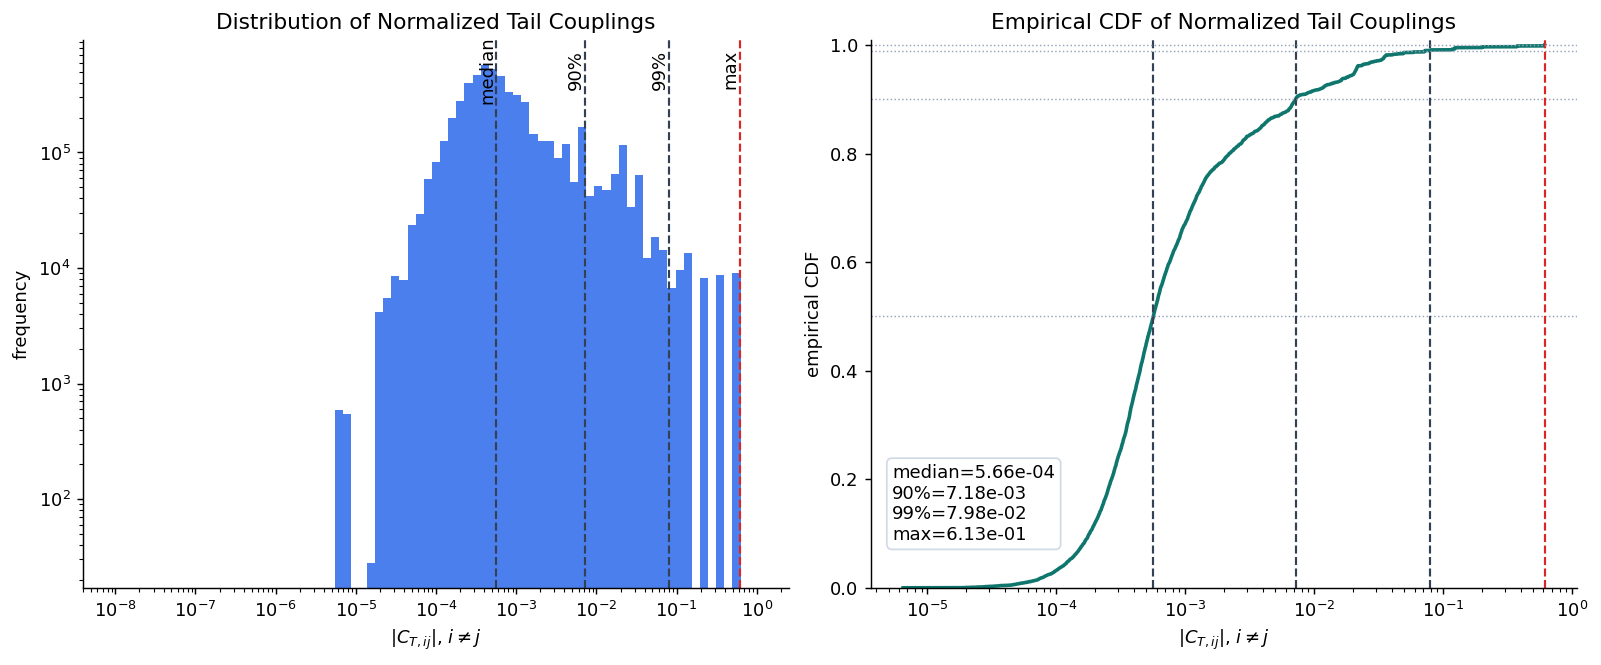

In [83]:
# REQUIRED_REFRESH_FIGURE_OUTPUT: normalized tail coupling distribution
from datetime import datetime
from IPython.display import display

print("REQUIRED_REFRESH_FIGURE_OUTPUT: normalized tail coupling distribution")
print(f"  refresh started: {datetime.now().isoformat(timespec='seconds')}")

tail_diag = np.maximum(np.real(np.diag(ATT)), 1e-300)
if ATT.shape[0] < 2:
    print(f"  C_T shape: {ATT.shape}")
    print("  tail block has fewer than 2 modes, so there are no off-diagonal tail couplings to summarize.")
    fig, ax = plt.subplots(figsize=(7.8, 4.8), constrained_layout=True)
    ax.axis("off")
    ax.text(0.5, 0.55, "No off-diagonal tail couplings", ha="center", va="center", fontsize=15, weight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.40, f"tail block size = {ATT.shape[0]}\nIncrease MATRIX_TOY_HM or decrease MATRIX_ACTIVE_TOPK", ha="center", va="center", fontsize=11, transform=ax.transAxes)
else:
    inv_sqrt_tail = 1.0 / np.sqrt(tail_diag)
    C_T = inv_sqrt_tail[:, None] * ATT * inv_sqrt_tail[None, :]
    C_T = 0.5 * (C_T + C_T.conj().T)
    offdiag_mask = ~np.eye(C_T.shape[0], dtype=bool)
    offdiag_vals = np.abs(C_T[offdiag_mask])
    quantiles = np.quantile(offdiag_vals, [0.5, 0.9, 0.99])
    max_offdiag = float(np.max(offdiag_vals))

    print(f"  C_T shape: {C_T.shape}")
    print(f"  median |offdiag(C_T)|: {quantiles[0]:.3e}")
    print(f"  90% quantile |offdiag(C_T)|: {quantiles[1]:.3e}")
    print(f"  99% quantile |offdiag(C_T)|: {quantiles[2]:.3e}")
    print(f"  max |offdiag(C_T)|: {max_offdiag:.3e}")

    vals_sorted = np.sort(offdiag_vals)
    y_cdf = np.arange(1, vals_sorted.size + 1, dtype=np.float64) / float(vals_sorted.size)
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.0), constrained_layout=True)
    axes[0].hist(offdiag_vals, bins=np.logspace(-8, 0, 80), color="#2563eb", alpha=0.82)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(r"$|C_{T,ij}|$, $i \neq j$")
    axes[0].set_ylabel("frequency")
    axes[0].set_title("Distribution of Normalized Tail Couplings")
    for value, label in [(quantiles[0], "median"), (quantiles[1], "90%"), (quantiles[2], "99%"), (max_offdiag, "max")]:
        axes[0].axvline(value, color="#dc2626" if label == "max" else "#334155", lw=1.2, linestyle="--")
        axes[0].text(value, axes[0].get_ylim()[1] * 0.55, label, rotation=90, va="center", ha="right")

    axes[1].plot(vals_sorted, y_cdf, color="#0f766e", lw=2.0)
    axes[1].set_xscale("log")
    axes[1].set_ylim(0.0, 1.01)
    axes[1].set_xlabel(r"$|C_{T,ij}|$, $i \neq j$")
    axes[1].set_ylabel("empirical CDF")
    axes[1].set_title("Empirical CDF of Normalized Tail Couplings")
    for value, label, y in [(quantiles[0], "median", 0.5), (quantiles[1], "90%", 0.9), (quantiles[2], "99%", 0.99), (max_offdiag, "max", 1.0)]:
        axes[1].axvline(value, color="#dc2626" if label == "max" else "#334155", lw=1.2, linestyle="--")
        axes[1].axhline(y, color="#94a3b8", lw=0.8, linestyle=":")
    axes[1].text(
        0.03,
        0.08,
        f"median={quantiles[0]:.2e}\n90%={quantiles[1]:.2e}\n99%={quantiles[2]:.2e}\nmax={max_offdiag:.2e}",
        transform=axes[1].transAxes,
        ha="left",
        va="bottom",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "#cbd5e1"},
    )

png_path = PICTURE_DIR / f"{OUTPUT_BASENAME_TAIL}.png"
pdf_path = PICTURE_DIR / f"{OUTPUT_BASENAME_TAIL}.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
for path in (png_path, pdf_path):
    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"required figure was not written correctly: {path}")
    print(f"  saved {path} | bytes={path.stat().st_size} | mtime={datetime.fromtimestamp(path.stat().st_mtime).isoformat(timespec='seconds')}")
display(fig)
plt.close(fig)


## Quick Consistency Checks

In [84]:
active_min = active_j.min(axis=0)
active_max = active_j.max(axis=0)
box_contains_active = bool(
    np.all(active_min >= -box_radii) and np.all(active_max <= box_radii)
)
expected_files = [
    PICTURE_DIR / f"{OUTPUT_BASENAME_ACTIVE}.png",
    PICTURE_DIR / f"{OUTPUT_BASENAME_ACTIVE}.pdf",
    PICTURE_DIR / f"{OUTPUT_BASENAME_DECAY}.png",
    PICTURE_DIR / f"{OUTPUT_BASENAME_DECAY}.pdf",
    PICTURE_DIR / f"{OUTPUT_BASENAME_BLOCKS}.png",
    PICTURE_DIR / f"{OUTPUT_BASENAME_BLOCKS}.pdf",
    PICTURE_DIR / f"{OUTPUT_BASENAME_TAIL}.png",
    PICTURE_DIR / f"{OUTPUT_BASENAME_TAIL}.pdf",
    PICTURE_DIR / f"{OUTPUT_BASENAME_SPECTRUM}.png",
    PICTURE_DIR / f"{OUTPUT_BASENAME_SPECTRUM}.pdf",
]
missing = [str(p) for p in expected_files if not p.exists()]
print("Final notebook checks")
print("-" * 80)
print(f"box_contains_active: {box_contains_active}")
print(f"expected_output_count: {len(expected_files)}")
print(f"missing_outputs: {missing}")
if not box_contains_active:
    raise AssertionError("Enclosing box B does not contain every active Fourier mode.")
if missing:
    raise AssertionError(f"Missing expected figure outputs: {missing}")

Final notebook checks
--------------------------------------------------------------------------------
box_contains_active: True
expected_output_count: 10
missing_outputs: []
